In [23]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [25]:
K = 5
STRATEGY = "uniform"

K_FRAME_PATH = Path(f"../data/k_frames/K{K}_{STRATEGY}.csv")
NORMALIZATION_PATH = Path("../data/processed/normalization_stats.json")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(K_FRAME_PATH)

print(df.head())
print(df.columns)
print(df.groupby(["split", "class_name"]).size())

  split  site_id class_name  label  K strategy  selected_frame_count  \
0  test       26     looted      1  5  uniform                     5   
1  test       27     looted      1  5  uniform                     5   
2  test       29     looted      1  5  uniform                     5   
3  test       30     looted      1  5  uniform                     5   
4  test       31     looted      1  5  uniform                     5   

   frame_1_index frame_1_name                                    frame_1_path  \
0              0  2016_01.jpg  ..\data\processed_images\looted\26\2016_01.jpg   
1              0  2016_01.jpg  ..\data\processed_images\looted\27\2016_01.jpg   
2              0  2016_01.jpg  ..\data\processed_images\looted\29\2016_01.jpg   
3              0  2016_01.jpg  ..\data\processed_images\looted\30\2016_01.jpg   
4              0  2016_01.jpg  ..\data\processed_images\looted\31\2016_01.jpg   

   ...                                    frame_2_path frame_3_index  \
0  ...  

In [26]:
with open(NORMALIZATION_PATH, "r") as f:
    norm_stats = json.load(f)

mean = norm_stats["mean"]
std = norm_stats["std"]

print("Mean:", mean)
print("Std:", std)

Mean: [0.6641249441448802, 0.5746265725068144, 0.42835551291561075]
Std: [0.17935859533908458, 0.1680383227926673, 0.17305869328805765]


In [27]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val_1"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("Train class counts:")
print(train_df["label"].value_counts())

print("Validation class counts:")
print(val_df["label"].value_counts())

print("Test class counts:")
print(test_df["label"].value_counts())

Train: 524
Val: 18
Test: 61
Train class counts:
label
0    460
1     64
Name: count, dtype: int64
Validation class counts:
label
1    9
0    9
Name: count, dtype: int64
Test class counts:
label
0    35
1    26
Name: count, dtype: int64


In [28]:
image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [29]:
class ChangeAwareKFrameDataset(Dataset):
    def __init__(self, dataframe, k, transform=None, training=False, frame_drop_prob=0.25):
        self.df = dataframe
        self.k = k
        self.transform = transform
        self.training = training
        self.frame_drop_prob = frame_drop_prob

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        frames = []

        for i in range(1, self.k + 1):
            img_path = row[f"frame_{i}_path"]
            img = Image.open(img_path).convert("RGB")

            if self.transform:
                img = self.transform(img)

            frames.append(img)

        frames = torch.stack(frames, dim=0)  # [K, 3, 224, 224]

        # temporal mask: 1 = frame available, 0 = dropped frame
        temporal_mask = torch.ones(self.k, dtype=torch.float32)

        # Training-time frame drop
        # Keep frame 1 as reference frame. Drop only later frames.
        if self.training and self.frame_drop_prob > 0 and self.k > 1:
            drop_indices = []

            for i in range(1, self.k):
                if random.random() < self.frame_drop_prob:
                    drop_indices.append(i)

            # Make sure not all target frames are dropped
            if len(drop_indices) == self.k - 1:
                keep_one = random.choice(drop_indices)
                drop_indices.remove(keep_one)

            for i in drop_indices:
                frames[i] = torch.zeros_like(frames[i])
                temporal_mask[i] = 0.0

        label = torch.tensor(int(row["label"]), dtype=torch.long)

        return frames, temporal_mask, label

In [30]:
BATCH_SIZE = 8

train_dataset = ChangeAwareKFrameDataset(
    train_df,
    k=K,
    transform=image_transform,
    training=True,
    frame_drop_prob=0.0
)

val_dataset = ChangeAwareKFrameDataset(
    val_df,
    k=K,
    transform=image_transform,
    training=False,
    frame_drop_prob=0.0
)

test_dataset = ChangeAwareKFrameDataset(
    test_df,
    k=K,
    transform=image_transform,
    training=False,
    frame_drop_prob=0.0
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 66
Val batches: 3
Test batches: 8


In [31]:
frames, temporal_mask, labels = next(iter(train_loader))

print("Frames shape:", frames.shape)
print("Temporal mask shape:", temporal_mask.shape)
print("Labels shape:", labels.shape)
print("Temporal mask example:")
print(temporal_mask[0])

Frames shape: torch.Size([8, 5, 3, 224, 224])
Temporal mask shape: torch.Size([8, 5])
Labels shape: torch.Size([8])
Temporal mask example:
tensor([1., 1., 1., 1., 1.])


In [32]:
class ProposedChangeAwareModel(nn.Module):
    def __init__(self, num_classes=2, feature_dim=128):
        super(ProposedChangeAwareModel, self).__init__()

        self.feature_dim = feature_dim
        self.change_feature_dim = feature_dim * 2

        # CNN encoder
        self.cnn_encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            nn.Conv2d(64, feature_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(feature_dim),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14

            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Attention over change-aware features
        self.temporal_attention = nn.Sequential(
            nn.Linear(self.change_feature_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(self.change_feature_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, temporal_mask=None):
        # x shape: [B, K, 3, 224, 224]
        batch_size, k, c, h, w = x.shape

        # Combine batch and time
        x = x.reshape(batch_size * k, c, h, w)

        # Extract CNN features
        features = self.cnn_encoder(x)

        # [B*K, feature_dim] -> [B, K, feature_dim]
        features = features.reshape(batch_size, k, self.feature_dim)

        # Reference frame = first frame
        reference_feature = features[:, 0:1, :]  # [B, 1, feature_dim]

        # Change-aware feature = original feature + absolute difference
        change_feature = torch.abs(features - reference_feature)

        change_aware_features = torch.cat(
            [features, change_feature],
            dim=-1
        )  # [B, K, feature_dim*2]

        # Attention scores
        scores = self.temporal_attention(change_aware_features)  # [B, K, 1]

        # Apply temporal mask if provided
        if temporal_mask is not None:
            temporal_mask = temporal_mask.unsqueeze(-1)  # [B, K, 1]
            scores = scores.masked_fill(temporal_mask == 0, -1e9)

        # Attention weights
        weights = torch.softmax(scores, dim=1)  # [B, K, 1]

        # Weighted temporal fusion
        fused_feature = torch.sum(change_aware_features * weights, dim=1)

        # Classification
        output = self.classifier(fused_feature)

        return output

In [33]:
model = ProposedChangeAwareModel(
    num_classes=2,
    feature_dim=128
).to(device)

print(model)

ProposedChangeAwareModel(
  (cnn_encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, mome

In [34]:
class_counts = train_df["label"].value_counts().sort_index()
print(class_counts)

num_preserved = class_counts[0]
num_looted = class_counts[1]

total = num_preserved + num_looted

weight_preserved = total / (2 * num_preserved)
weight_looted = total / (2 * num_looted)

class_weights = torch.tensor(
    [weight_preserved, weight_looted],
    dtype=torch.float32
).to(device)

print("Class weights:", class_weights)

label
0    460
1     64
Name: count, dtype: int64
Class weights: tensor([0.5696, 4.0938])


In [35]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [36]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for frames, temporal_mask, labels in tqdm(dataloader):
        frames = frames.to(device)
        temporal_mask = temporal_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(frames, temporal_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * frames.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [37]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for frames, temporal_mask, labels in tqdm(dataloader):
            frames = frames.to(device)
            temporal_mask = temporal_mask.to(device)
            labels = labels.to(device)

            outputs = model(frames, temporal_mask)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * frames.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = None

    cm = confusion_matrix(all_labels, all_preds)

    metrics = {
        "loss": epoch_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm
    }

    return metrics

In [38]:
EPOCHS = 10

experiment_name = f"proposed_change_aware_K{K}_{STRATEGY}_noframedrop"

best_val_f1 = -1.0
best_model_path = RESULTS_DIR / f"{experiment_name}_best.pth"

history = []

print("Experiment:", experiment_name)
print("Saving to:", best_model_path)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']}"
    )

    history.append({
        "epoch": epoch + 1,
        "K": K,
        "strategy": STRATEGY,
        "model": "proposed_change_aware_attention",
        "frame_drop_prob": 0.25,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    })

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), best_model_path)
        print("Best proposed model saved ✅")

Experiment: proposed_change_aware_K5_uniform_noframedrop
Saving to: ..\results\proposed_change_aware_K5_uniform_noframedrop_best.pth

Epoch 1/10


100%|██████████| 3/3 [00:00<00:00,  3.62it/s]


Train Loss: 0.6109 | Train Acc: 0.7481
Val Loss: 1.3820 | Val Acc: 0.5556 | Val Precision: 1.0000 | Val Recall: 0.1111 | Val F1: 0.2000 | Val AUC: 0.49382716049382724
Best proposed model saved ✅

Epoch 2/10


100%|██████████| 3/3 [00:00<00:00,  3.26it/s]


Train Loss: 0.5658 | Train Acc: 0.7939
Val Loss: 1.3348 | Val Acc: 0.5000 | Val Precision: 0.5000 | Val Recall: 0.1111 | Val F1: 0.1818 | Val AUC: 0.4074074074074074

Epoch 3/10


...

Train Loss: 0.3739 | Train Acc: 0.8626
Val Loss: 1.5570 | Val Acc: 0.3889 | Val Precision: 0.4167 | Val Recall: 0.5556 | Val F1: 0.4762 | Val AUC: 0.48148148148148145

Epoch 9/10


100%|██████████| 3/3 [00:00<00:00,  3.83it/s]


Train Loss: 0.3600 | Train Acc: 0.8492
Val Loss: 1.8896 | Val Acc: 0.3889 | Val Precision: 0.4167 | Val Recall: 0.5556 | Val F1: 0.4762 | Val AUC: 0.5061728395061728

Epoch 10/10


100%|██████████| 3/3 [00:00<00:00,  3.43it/s]

Train Loss: 0.2984 | Train Acc: 0.8836
Val Loss: 1.7328 | Val Acc: 0.4444 | Val Precision: 0.4545 | Val Recall: 0.5556 | Val F1: 0.5000 | Val AUC: 0.46913580246913583


In [39]:
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / f"{experiment_name}_history.csv", index=False)

history_df

,epoch,K,strategy,model,frame_drop_prob,train_loss,train_accuracy,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_auc
0,1,5,uniform,proposed_change_aware_attention,0.25,0.610930,0.748092,1.382018,0.555556,1.000000,0.111111,0.200000,0.493827
1,2,5,uniform,proposed_change_aware_attention,0.25,0.565770,0.793893,1.334776,0.500000,0.500000,0.111111,0.181818,0.407407
2,3,5,uniform,proposed_change_aware_attention,0.25,0.560707,0.706107,0.626505,0.500000,0.500000,1.000000,0.666667,0.580247
3,4,5,uniform,proposed_change_aware_attention,0.25,0.552749,0.814885,0.698203,0.500000,0.500000,0.888889,0.640000,0.530864
4,5,5,uniform,proposed_change_aware_attention,0.25,0.462725,0.822519,0.738115,0.444444,0.466667,0.777778,0.583333,0.493827
5,6,5,uniform,proposed_change_aware_attention,0.25,0.350531,0.883588,2.460948,0.444444,0.444444,0.444444,0.444444,0.444444
6,7,5,uniform,proposed_change_aware_attention,0.25,0.437606,0.833969,0.769716,0.500000,0.500000,1.000000,0.666667,0.666667
7,8,5,uniform,proposed_change_aware_attention,0.25,0.373933,0.862595,1.557029,0.388889,0.416667,0.555556,0.476190,0.481481
8,9,5,uniform,proposed_change_aware_attention,0.25,0.360006,0.849237,1.889647,0.388889,0.416667,0.555556,0.476190,0.506173
9,10,5,uniform,proposed_change_aware_attention,0.25,0.298421,0.883588,1.732770,0.444444,0.454545,0.555556,0.500000,0.469136


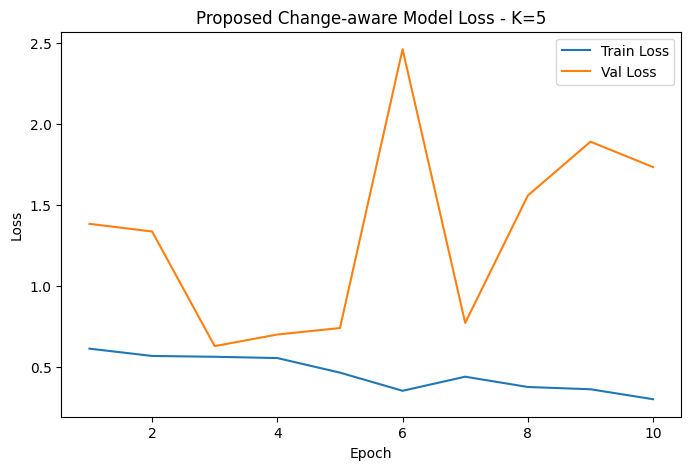

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Proposed Change-aware Model Loss - K={K}")
plt.legend()
plt.show()

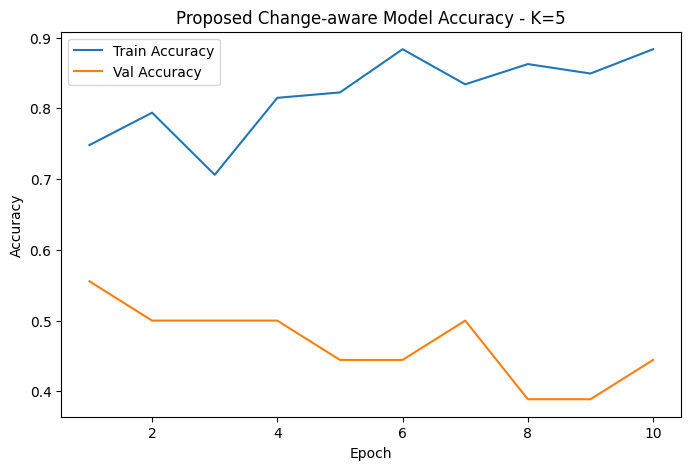

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Proposed Change-aware Model Accuracy - K={K}")
plt.legend()
plt.show()

In [42]:
best_model = ProposedChangeAwareModel(
    num_classes=2,
    feature_dim=128
).to(device)

print("Loading:", best_model_path)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_metrics = evaluate(best_model, test_loader, criterion, device)

print("Test Results:")
print("Accuracy:", test_metrics["accuracy"])
print("Precision:", test_metrics["precision"])
print("Recall:", test_metrics["recall"])
print("F1:", test_metrics["f1"])
print("AUC:", test_metrics["auc"])
print("Confusion Matrix:")
print(test_metrics["confusion_matrix"])

Loading: ..\results\proposed_change_aware_K5_uniform_noframedrop_best.pth


100%|██████████| 8/8 [00:03<00:00,  2.62it/s]

Test Results:
Accuracy: 0.4262295081967213
Precision: 0.4262295081967213
Recall: 1.0
F1: 0.5977011494252874
AUC: 0.6395604395604395
Confusion Matrix:
[[ 0 35]
 [ 0 26]]


In [43]:
test_result_df = pd.DataFrame([{
    "model": "proposed_change_aware_attention",
    "K": K,
    "strategy": STRATEGY,
    "frame_drop_prob": 0.25,
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"]
}])

test_result_df.to_csv(
    RESULTS_DIR / f"{experiment_name}_test_results.csv",
    index=False
)

test_result_df

,model,K,strategy,frame_drop_prob,test_accuracy,test_precision,test_recall,test_f1,test_auc
0,proposed_change_aware_attention,5,uniform,0.25,0.42623,0.42623,1.0,0.597701,0.63956


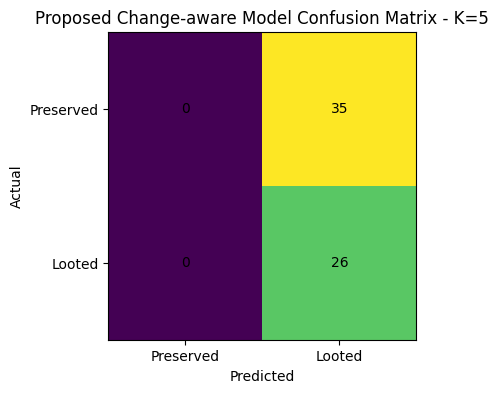

In [44]:
cm = test_metrics["confusion_matrix"]

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Proposed Change-aware Model Confusion Matrix - K={K}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Preserved", "Looted"])
plt.yticks([0, 1], ["Preserved", "Looted"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()